In [9]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

from sklearn.linear_model import Lasso, Ridge
from pyprojroot import here

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import config
from model_utils import ModelSelector, train_test_split, one_hot_encode, scale_data


In [10]:
data = pd.read_parquet(config.FPL_DATA_PATH)
data.head()

,status,web_name,team_name,position,match_id,now_cost,gw,id,selected_by_percent,player_code,corners_and_indirect_freekicks_order,team_code,direct_freekicks_order,dreamteam_count,team_strength,chance_of_playing_next_round,penalties_order,season_id,xg_ema_4,xg_per_90_ema_4,xgot_ema_4,total_shots_ema_4,shots_on_target_ema_4,touches_opposition_box_ema_4,big_chances_missed_ema_4,xa_ema_4,xa_per_90_ema_4,expected_goal_involvements_ema_4,chances_created_ema_4,creativity_ema_4,final_third_passes_ema_4,accurate_crosses_ema_4,successful_dribbles_ema_4,touches_ema_4,accurate_passes_ema_4,recoveries_ema_4,tackles_ema_4,tackles_won_ema_4,interceptions_ema_4,blocks_ema_4,clearances_ema_4,duels_won_ema_4,duels_lost_ema_4,ground_duels_won_ema_4,aerial_duels_won_ema_4,headed_clearances_ema_4,influence_ema_4,saves_ema_4,goals_prevented_ema_4,was_fouled_ema_4,high_claim_ema_4,sweeper_actions_ema_4,gk_accurate_passes_ema_4,gk_accurate_long_balls_ema_4,accurate_long_balls_ema_4,dribbled_past_ema_4,expected_goal_involvements_per_90_ema_4,expected_goals_conceded_per_90_ema_4,event_points_lagged_1,total_points_lagged_1,minutes_played_lagged_1,goals_lagged_1,assists_lagged_1,bonus_lagged_1,goals_conceded_lagged_1,team_goals_conceded_lagged_1,penalties_missed_lagged_1,penalties_scored_lagged_1,fouls_committed_lagged_1,offsides_lagged_1,start_min_lagged_1,finish_min_lagged_1,event_points
0,a,Milner,Brighton,MID,24-25-prem-everton-vs-brighton-&-hove-albion,5.0,1,134,0.1,15157,1,36,7,0,3,0,6,2425,0.0000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0000,0.000000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.000,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
1,a,Milner,Brighton,MID,24-25-prem-brighton-&-hove-albion-vs-mancheste...,5.0,2,134,0.1,15157,1,36,7,0,3,0,6,2425,0.0000,0.000000,0.0,0.00,0.00,2.0,0.0,0.1100,0.120732,0.110,3.00,43.800,2.00,2.00,0.00,48.00,28.00,0.00,4.00,2.00,0.00,2.00,0.00,4.00,2.00,4.00,0.0,0.0,22.400,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1.00,0.0,0.120732,0.493902,2,2,82,0,0,0,0,0,0,0,1,0,0,82,2
2,d,Milner,Brighton,MID,24-25-prem-arsenal-vs-brighton-&-hove-albion,5.0,3,134,0.1,15157,1,36,7,0,3,75,6,2425,0.0640,0.078904,0.0,0.80,0.40,2.0,0.0,0.0820,0.092165,0.190,2.20,52.760,3.60,1.60,0.40,45.60,25.60,0.80,2.80,1.20,0.40,1.20,0.80,3.60,1.60,3.60,0.0,0.0,24.880,0.0,0.0,0.40,0.0,0.0,0.0,0.0,0.60,0.0,0.225316,1.169218,2,4,73,0,0,0,0,1,0,0,1,0,0,73,1
3,a,Milner,Brighton,MID,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,5.0,38,134,0.0,15157,8,36,7,0,3,100,6,2425,0.0384,0.047342,0.0,0.48,0.24,1.2,0.0,0.0492,0.055299,0.238,1.32,58.176,2.16,0.96,0.24,28.96,16.16,0.48,1.68,0.72,0.64,0.72,0.48,2.16,1.36,2.16,0.0,0.0,26.368,0.0,0.0,0.24,0.0,0.0,0.0,0.0,0.36,0.0,0.791660,4.894472,1,5,17,0,0,0,0,0,0,0,1,0,0,17,1
4,a,Milner,Brighton,MID,25-26-prem-brighton-hove-albion-vs-fulham,4.9,1,170,0.1,15157,5,36,7,0,3,100,1,2526,0.0000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0000,0.000000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.000,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [11]:
len(data.select_dtypes(exclude=np.number).columns)

5

In [12]:
data.season_id.unique()

array([2425, 2526])

In [13]:
X_train, y_train, X_valid, y_valid, X_test, y_test = train_test_split(data)
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape, X_test.shape, y_test.shape

((6677, 72), (6677,), (2429, 72), (2429,), (2461, 72), (2461,))

In [17]:
X_train, X_valid, X_test = one_hot_encode(X_train, X_valid, X_test, cols_to_encode=["position", "status"])

In [18]:
X_train.head()

,now_cost,gw,id,selected_by_percent,player_code,corners_and_indirect_freekicks_order,team_code,direct_freekicks_order,dreamteam_count,team_strength,chance_of_playing_next_round,penalties_order,season_id,xg_ema_4,xg_per_90_ema_4,xgot_ema_4,total_shots_ema_4,shots_on_target_ema_4,touches_opposition_box_ema_4,big_chances_missed_ema_4,xa_ema_4,xa_per_90_ema_4,expected_goal_involvements_ema_4,chances_created_ema_4,creativity_ema_4,final_third_passes_ema_4,accurate_crosses_ema_4,successful_dribbles_ema_4,touches_ema_4,accurate_passes_ema_4,recoveries_ema_4,tackles_ema_4,tackles_won_ema_4,interceptions_ema_4,blocks_ema_4,clearances_ema_4,duels_won_ema_4,duels_lost_ema_4,ground_duels_won_ema_4,aerial_duels_won_ema_4,headed_clearances_ema_4,influence_ema_4,saves_ema_4,goals_prevented_ema_4,was_fouled_ema_4,high_claim_ema_4,sweeper_actions_ema_4,gk_accurate_passes_ema_4,gk_accurate_long_balls_ema_4,accurate_long_balls_ema_4,dribbled_past_ema_4,expected_goal_involvements_per_90_ema_4,expected_goals_conceded_per_90_ema_4,event_points_lagged_1,total_points_lagged_1,minutes_played_lagged_1,goals_lagged_1,assists_lagged_1,bonus_lagged_1,goals_conceded_lagged_1,team_goals_conceded_lagged_1,penalties_missed_lagged_1,penalties_scored_lagged_1,fouls_committed_lagged_1,offsides_lagged_1,start_min_lagged_1,finish_min_lagged_1,position_DEF,position_FWD,position_GKP,position_MID,status_a,status_d,status_i,status_n,status_s,status_u
0,5.0,1,134,0.1,15157,1,36,7,0,3,0,6,2425,0.000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
1,5.0,2,134,0.1,15157,1,36,7,0,3,0,6,2425,0.000,0.000000,0.0,0.0,0.0,2.0,0.0,0.110,0.120732,0.11,3.0,43.80,2.0,2.0,0.0,48.0,28.0,0.0,4.0,2.0,0.0,2.0,0.0,4.0,2.0,4.0,0.0,0.0,22.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.120732,0.493902,2,2,82,0,0,0,0,0,0,0,1,0,0,82,0,0,0,1,1,0,0,0,0,0
2,5.0,3,134,0.1,15157,1,36,7,0,3,75,6,2425,0.064,0.078904,0.0,0.8,0.4,2.0,0.0,0.082,0.092165,0.19,2.2,52.76,3.6,1.6,0.4,45.6,25.6,0.8,2.8,1.2,0.4,1.2,0.8,3.6,1.6,3.6,0.0,0.0,24.88,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.6,0.0,0.225316,1.169218,2,4,73,0,0,0,0,1,0,0,1,0,0,73,0,0,0,1,0,1,0,0,0,0
3,5.0,1,236,2.1,17761,8,11,7,0,3,0,6,2425,0.000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
4,4.9,2,236,1.6,17761,8,11,7,0,3,100,6,2425,0.010,0.010000,0.0,1.0,0.0,1.0,0.0,0.010,0.010000,0.02,1.0,10.80,10.0,0.0,0.0,68.0,45.0,5.0,2.0,1.0,4.0,1.0,2.0,3.0,8.0,2.0,1.0,2.0,17.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,0.020000,1.430000,0,0,90,0,0,0,0,3,0,0,2,0,0,91,1,0,0,0,1,0,0,0,0,0


In [19]:
X_train, X_valid, X_test = scale_data(X_train, X_valid, X_test)

In [20]:
param_grid =[
    {"alpha": np.arange(0.001, 1, .01)},
    {"alpha": np.arange(0.001, 1, .01)}
]

In [21]:
selector = ModelSelector(random_state=77)


In [22]:
lasso, ridge = Lasso(), Ridge()

In [23]:
model = [lasso, ridge]
model_names = ["Lasso", "Ridge"]


In [24]:
results, best_params = selector.params_search(models=model,
                       models_names=model_names,
                       params_grid=param_grid,
                       X_train=X_train,
                       y_train=y_train,
                       cv=5,
                       n_iter=30,
                       scoring="neg_mean_squared_error")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [25]:
results

,data,name,cv_mean_neg_mean_squared_error,best_params,mse,mae,r2
0,train,Lasso,-7.281768,{'alpha': 0.05099999999999999},7.126765,1.896408,0.166187
1,train,Ridge,-7.734914,{'alpha': 0.9609999999999999},6.956778,1.879630,0.186075


In [26]:
valid_results, y_preds = selector.evaluate(best_params, X_valid, y_valid)


In [27]:
valid_results

,data,model_name,mse,mae,r2
1,test,Ridge,7.925395,1.983162,0.136998
0,test,Lasso,7.681472,1.970858,0.163559


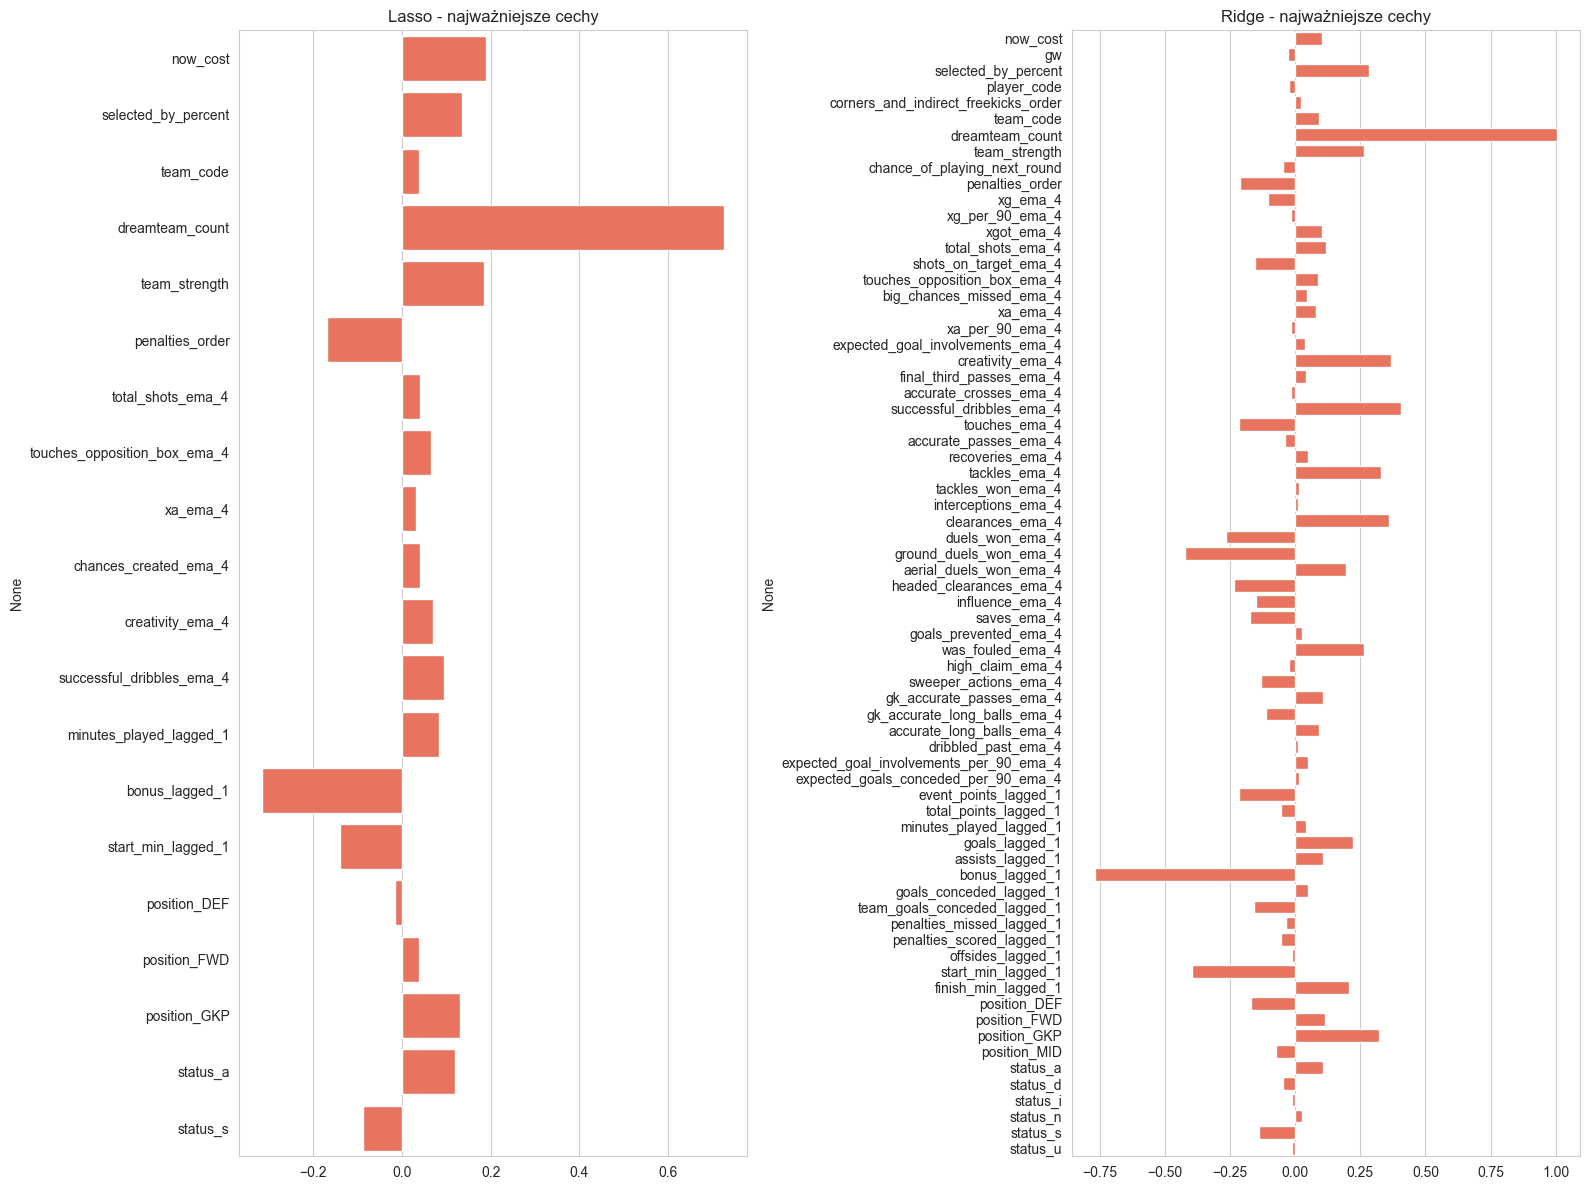

In [28]:
threshold = .01
fig, ax = plt.subplots(1, 2, figsize=(16, 12))

for i, model in enumerate(["Lasso", "Ridge"]):
    coefs = best_params[model].coef_
    mask = ~np.isclose(coefs, 0.0, atol=threshold)

    sns.barplot(x=coefs[mask], y=X_train.columns[mask], ax=ax[i], color="tomato")
    ax[i].set_title(f"{model} - najważniejsze cechy")

plt.tight_layout()

In [29]:
frames = []

for i, model in enumerate(["Lasso", "Ridge"]):
    coefs = best_params[model].coef_
    temp_frame = pd.DataFrame({
        "feature": X_train.columns,
        "coef": coefs,
        "model": model
    })
    frames.append(temp_frame)
coefs_frame = pd.concat(frames, ignore_index=True)

In [30]:
coefs_frame[coefs_frame.model == "Ridge"].sort_values(
    by="coef",
    key=abs,
    ascending=False
).head(10)

,feature,coef,model
85,dreamteam_count,1.004194,Ridge
135,bonus_lagged_1,-0.766812,Ridge
115,ground_duels_won_ema_4,-0.423535,Ridge
104,successful_dribbles_ema_4,0.407770,Ridge
142,start_min_lagged_1,-0.394879,Ridge
101,creativity_ema_4,0.367658,Ridge
112,clearances_ema_4,0.359864,Ridge
108,tackles_ema_4,0.327855,Ridge
146,position_GKP,0.322845,Ridge
80,selected_by_percent,0.282021,Ridge


In [31]:
coefs_frame[coefs_frame.model == "Lasso"].sort_values(
    by="coef",
    key=abs,
    ascending=False
).head(10)

,feature,coef,model
8,dreamteam_count,0.726414,Lasso
58,bonus_lagged_1,-0.315277,Lasso
0,now_cost,0.188750,Lasso
9,team_strength,0.185646,Lasso
11,penalties_order,-0.169260,Lasso
65,start_min_lagged_1,-0.141059,Lasso
3,selected_by_percent,0.135852,Lasso
69,position_GKP,0.129896,Lasso
71,status_a,0.118900,Lasso
27,successful_dribbles_ema_4,0.094100,Lasso
